In [4]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [5]:
#load data
from tensorflow.keras.datasets import imdb

VOCAB_SIZE = 10000

(x_train,y_train),(x_test,y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

In [6]:
print(len(x_train))

25000


In [7]:
MAX_LEN = 500
x_train = pad_sequences(
    x_train,
    maxlen=MAX_LEN
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_LEN
)

In [8]:
print(x_train.shape)

(25000, 500)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential([
    
    Embedding(
        input_dim=10000,
        output_dim=32,
        input_length=500
    ),

    SimpleRNN(
        32
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

c:\Users\Bhavani\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.7091 - loss: 0.5584 - val_accuracy: 0.7760 - val_loss: 0.4852
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 189ms/step - accuracy: 0.8594 - loss: 0.3367 - val_accuracy: 0.8238 - val_loss: 0.4006
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 91ms/step - accuracy: 0.8892 - loss: 0.2769 - val_accuracy: 0.7664 - val_loss: 0.5864
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.8995 - loss: 0.2566 - val_accuracy: 0.8348 - val_loss: 0.4100
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9269 - loss: 0.1996 - val_accuracy: 0.8302 - val_loss: 0.4578
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9428 - loss: 0.1601 - val_accuracy: 0.8118 - val_loss: 0.4822
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - accuracy: 0.9627 - loss: 0.1110 - val_accuracy: 0.8386 - val_loss: 0.5254
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9748 - loss: 0.0772

In [13]:
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print(
    f"Accuracy: {accuracy*100:.2f}%"
)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8232 - loss: 0.6969
Accuracy: 82.32%


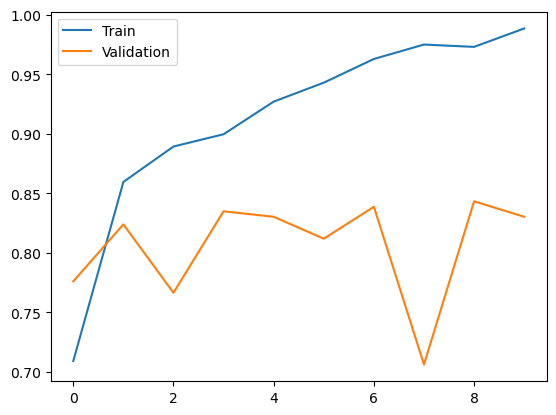

In [14]:
import matplotlib.pyplot as plt

plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.legend([
    'Train',
    'Validation'
])

plt.show()


In [15]:
model.save(
    "../models/sentiment_rnn.keras"
)
word_index = imdb.get_word_index()
import json

with open(
    "../models/word_index.json",
    "w"
) as f:
    
    json.dump(
        word_index,
        f
    )

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
